In [1]:
from pathlib import Path

# Change this only if your notebook is somewhere else
DATA_ROOT = Path("../data")

print("Data root:", DATA_ROOT.resolve())

subjects = sorted(DATA_ROOT.glob("SBJ*"))

print("Number of subjects:", len(subjects))

for subject in subjects:
    print(subject.name)

Data root: E:\IIT KGP IEEE\data
Number of subjects: 15
SBJ01
SBJ02
SBJ03
SBJ04
SBJ05
SBJ06
SBJ07
SBJ08
SBJ09
SBJ10
SBJ11
SBJ12
SBJ13
SBJ14
SBJ15


In [2]:
subject = DATA_ROOT / "SBJ01"

print("Subject:", subject)

for session in sorted(subject.glob("S*")):
    print(session)

Subject: ..\data\SBJ01
..\data\SBJ01\S01
..\data\SBJ01\S02
..\data\SBJ01\S03
..\data\SBJ01\S04
..\data\SBJ01\S05
..\data\SBJ01\S06
..\data\SBJ01\S07


In [3]:
session = subject / "S01"

print("Session contents:")

for item in session.iterdir():
    print(item.name)

Session contents:
Test
Train


In [4]:
train_dir = session / "Train"

for item in train_dir.iterdir():
    print(item.name)

trainData.mat
trainEvents.txt
trainLabels.txt
trainTargets.txt


In [5]:
import numpy as np
from scipy.io import loadmat

In [6]:
mat_file = train_dir / "trainData.mat"

mat = loadmat(mat_file)

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'trainData'])


In [7]:
data_variables = {
    key: value
    for key, value in mat.items()
    if not key.startswith("__")
}

for key, value in data_variables.items():
    print(key, value.shape)

trainData (8, 350, 1600)


In [8]:
eeg = list(data_variables.values())[0]

print("Original shape:", eeg.shape)

Original shape: (8, 350, 1600)


Train folder: E:\IIT KGP IEEE\data\SBJ01\S01\Train

MATLAB variables:
trainData (8, 350, 1600)

Original EEG shape: (8, 350, 1600)
Reorganized EEG shape: (1600, 8, 350)

Events shape: (1600,)
Targets shape: (1600,)
Labels shape: (20,)

BLOCK 1
EEG shape: (80, 8, 350)
Expected: (80, 8, 350)

Target object: 6

Number of target events: 10
Number of non-target events: 70

RUN STRUCTURE
Run  1 | Epochs  1- 8 | Objects: [7, 3, 4, 1, 6, 2, 8, 5] | Targets: [0, 0, 0, 0, 1, 0, 0, 0]
Run  2 | Epochs  9-16 | Objects: [2, 5, 4, 6, 1, 3, 8, 7] | Targets: [0, 0, 0, 1, 0, 0, 0, 0]
Run  3 | Epochs 17-24 | Objects: [8, 5, 1, 2, 4, 7, 6, 3] | Targets: [0, 0, 0, 0, 0, 0, 1, 0]
Run  4 | Epochs 25-32 | Objects: [8, 5, 7, 6, 2, 3, 1, 4] | Targets: [0, 0, 0, 1, 0, 0, 0, 0]
Run  5 | Epochs 33-40 | Objects: [2, 1, 7, 6, 5, 3, 4, 8] | Targets: [0, 0, 0, 1, 0, 0, 0, 0]
Run  6 | Epochs 41-48 | Objects: [2, 8, 4, 6, 1, 5, 7, 3] | Targets: [0, 0, 0, 1, 0, 0, 0, 0]
Run  7 | Epochs 49-56 | Objects: [5, 1, 8, 4, 3, 7,

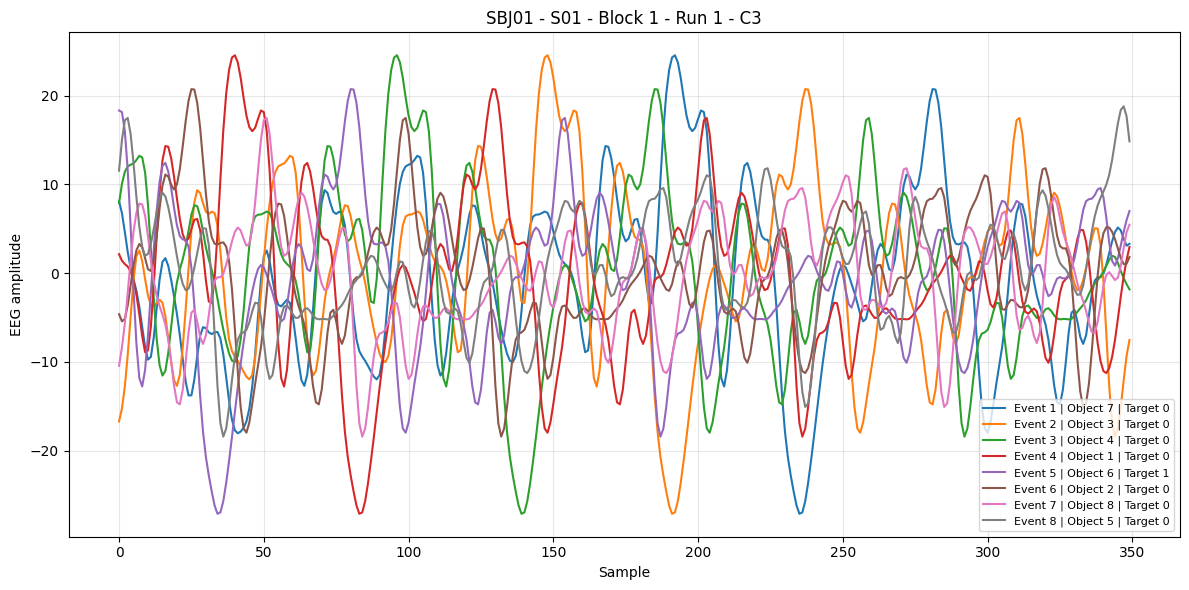

In [ ]:
# ============================================================
# BLOCK 1 — COMPLETE LOADING + INSPECTION
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ------------------------------------------------------------
# 1. DATA LOCATION
# ------------------------------------------------------------

DATA_ROOT = Path("../data")


subject = "SBJ01"
session = "S01"

train_dir = DATA_ROOT / subject / session / "Train"

print("Train folder:", train_dir.resolve())


# ------------------------------------------------------------
# 2. LOAD EEG DATA
# ------------------------------------------------------------

mat_file = train_dir / "trainData.mat"

mat = loadmat(mat_file)

# Find the actual MATLAB data variable
data_variables = {
    key: value
    for key, value in mat.items()
    if not key.startswith("__")
}

print("\nMATLAB variables:")
for key, value in data_variables.items():
    print(key, value.shape)

# Get EEG array
eeg = list(data_variables.values())[0]

print("\nOriginal EEG shape:", eeg.shape)


# ------------------------------------------------------------
# 3. CONVERT EEG
#    Original: (channels, samples, epochs)
#    Actual:   (8, 350, 1600)
#
#    Convert to:
#    (epochs, channels, samples)
#    = (1600, 8, 350)
# ------------------------------------------------------------

X = np.transpose(eeg, (2, 0, 1))

print("Reorganized EEG shape:", X.shape)


# ------------------------------------------------------------
# 4. LOAD EVENTS
# ------------------------------------------------------------

events_file = train_dir / "trainEvents.txt"

events = np.loadtxt(
    events_file,
    dtype=int
).flatten()

print("\nEvents shape:", events.shape)


# ------------------------------------------------------------
# 5. LOAD TARGETS
# ------------------------------------------------------------

targets_file = train_dir / "trainTargets.txt"

targets = np.loadtxt(
    targets_file,
    dtype=int
).flatten()

print("Targets shape:", targets.shape)


# ------------------------------------------------------------
# 6. LOAD BLOCK LABELS
# ------------------------------------------------------------

labels_file = train_dir / "trainLabels.txt"

labels = np.loadtxt(
    labels_file,
    dtype=int
).flatten()

print("Labels shape:", labels.shape)


# ------------------------------------------------------------
# 7. EXTRACT BLOCK 1
#
# Training:
# 10 runs × 8 events = 80 epochs per block
# ------------------------------------------------------------

BLOCK_SIZE = 10 * 8

block_1 = X[0:BLOCK_SIZE]

block_1_events = events[0:BLOCK_SIZE]

block_1_targets = targets[0:BLOCK_SIZE]

block_1_label = labels[0]


# ------------------------------------------------------------
# 8. BLOCK 1 INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BLOCK 1")
print("=" * 60)

print("EEG shape:", block_1.shape)
print("Expected: (80, 8, 350)")

print("\nTarget object:", block_1_label)

print("\nNumber of target events:",
      np.sum(block_1_targets == 1))

print("Number of non-target events:",
      np.sum(block_1_targets == 0))


# ------------------------------------------------------------
# 9. SHOW EACH RUN
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RUN STRUCTURE")
print("=" * 60)

for run in range(10):

    start = run * 8
    end = start + 8

    print(
        f"Run {run + 1:2d} | "
        f"Epochs {start + 1:2d}-{end:2d} | "
        f"Objects: {block_1_events[start:end].tolist()} | "
        f"Targets: {block_1_targets[start:end].tolist()}"
    )


# ------------------------------------------------------------
# 10. PLOT THE 8 EVENTS OF RUN 1
#     Channel 0 = C3
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

for event in range(8):

    plt.plot(
        block_1[event, 0, :],
        label=(
            f"Event {event + 1} | "
            f"Object {block_1_events[event]} | "
            f"Target {block_1_targets[event]}"
        )
    )

plt.xlabel("Sample")
plt.ylabel("EEG amplitude")
plt.title("SBJ01 - S01 - Block 1 - Run 1 - C3")

plt.legend(fontsize=8)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

EEG shape: (80, 8, 350)

MATLAB variables and their types:
trainData type = <class 'numpy.ndarray'> shape = (8, 350, 1600)

First epoch shape: (8, 350)

First epoch statistics:
 C3: min=-27.117, max=24.546, mean=-0.603, std=9.824
 Cz: min=-33.025, max=28.413, mean=-0.779, std=10.567
 C4: min=-21.355, max=23.411, mean=-1.164, std=9.373
CPz: min=-27.652, max=32.637, mean=-0.777, std=10.664
 P3: min=-22.374, max=29.840, mean=-0.652, std=9.374
 Pz: min=-24.025, max=31.180, mean=-0.687, std=10.073
 P4: min=-21.249, max=26.354, mean=-0.982, std=8.759
POz: min=-22.418, max=29.489, mean=-0.687, std=9.221


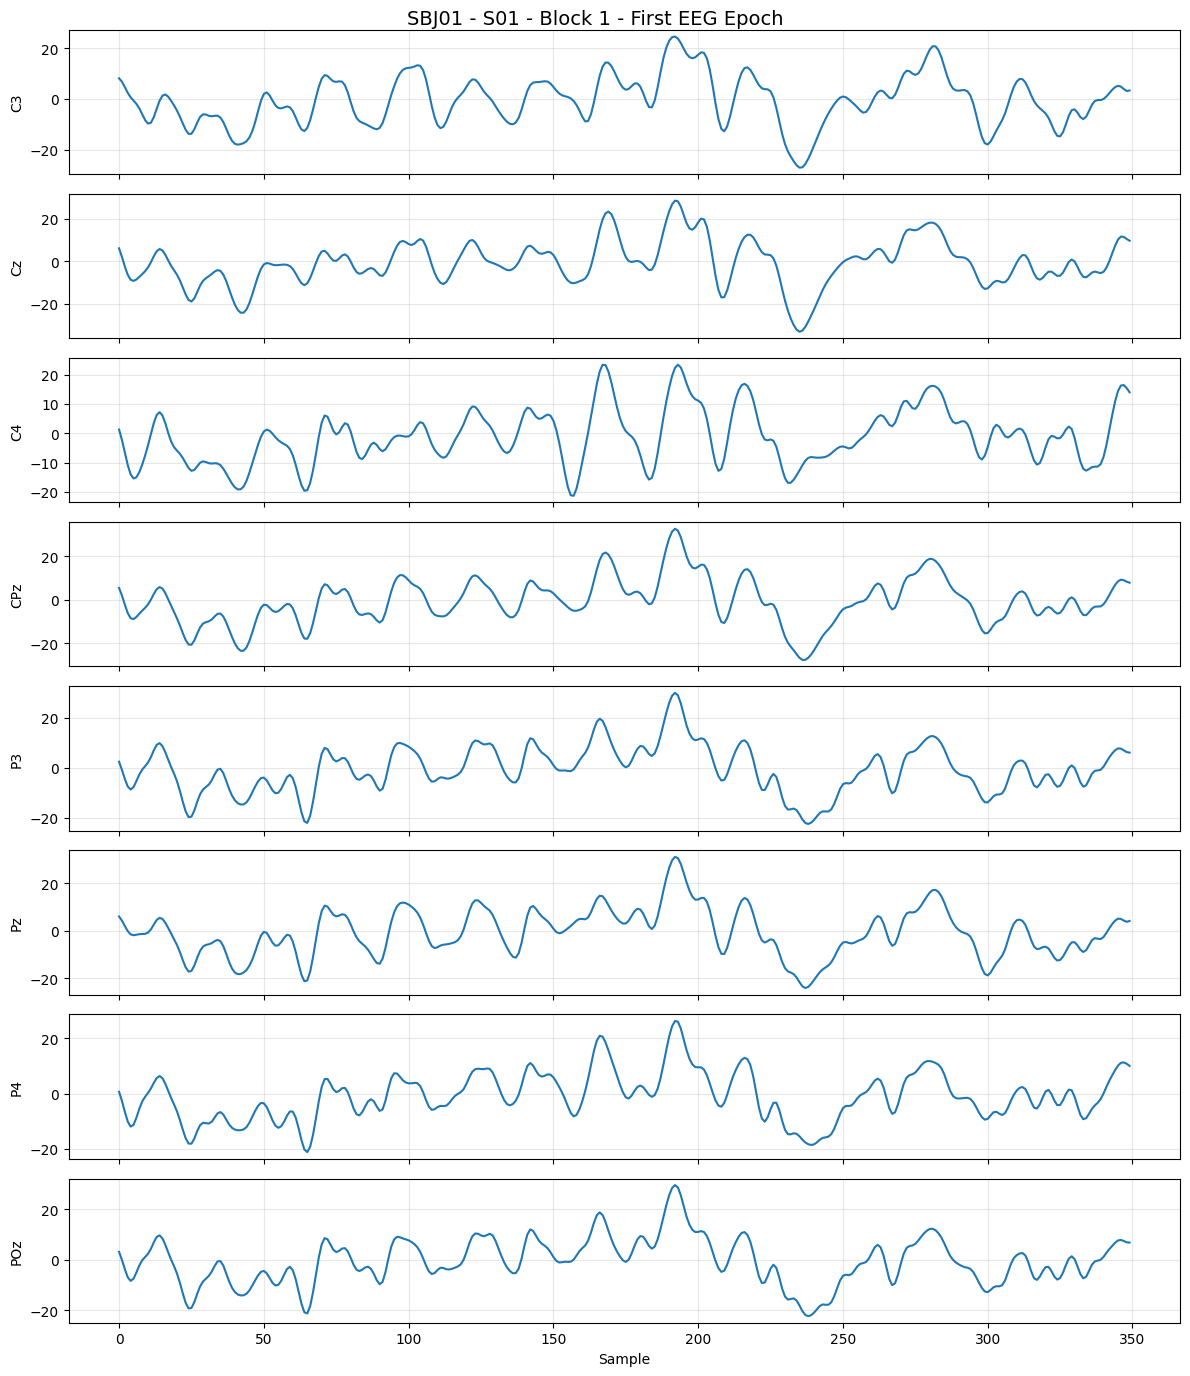

In [14]:
# ============================================================
# STEP 2 — INSPECT THE 350-SAMPLE EPOCH
# ============================================================

print("EEG shape:", block_1.shape)

# ------------------------------------------------------------
# Check sampling frequency from MATLAB file
# ------------------------------------------------------------

print("\nMATLAB variables and their types:")

for key, value in mat.items():
    if not key.startswith("__"):
        print(
            key,
            "type =", type(value),
            "shape =", getattr(value, "shape", None)
        )

# ------------------------------------------------------------
# Inspect the first epoch
# ------------------------------------------------------------

epoch = block_1[0]          # First event
channel_names = ["C3", "Cz", "C4", "CPz", "P3", "Pz", "P4", "POz"]

print("\nFirst epoch shape:", epoch.shape)

print("\nFirst epoch statistics:")

for ch in range(8):
    print(
        f"{channel_names[ch]:>3}: "
        f"min={epoch[ch].min():.3f}, "
        f"max={epoch[ch].max():.3f}, "
        f"mean={epoch[ch].mean():.3f}, "
        f"std={epoch[ch].std():.3f}"
    )

# ------------------------------------------------------------
# Plot all 8 channels of the first epoch
# ------------------------------------------------------------

fig, axes = plt.subplots(8, 1, figsize=(12, 14), sharex=True)

for ch in range(8):
    axes[ch].plot(epoch[ch])
    axes[ch].set_ylabel(channel_names[ch])
    axes[ch].grid(True, alpha=0.3)

axes[-1].set_xlabel("Sample")
fig.suptitle(
    "SBJ01 - S01 - Block 1 - First EEG Epoch",
    fontsize=14
)

plt.tight_layout()
plt.show()